In [1]:
# Cell 1 — Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load the master dataset
df = pd.read_csv("../dataset/master_dataset.csv", parse_dates=["Date"])
print(f"Shape: {df.shape}")
df.head()

Shape: (7928, 19)


,Date,Close,High,Low,Open,Volume,RSI,MACD,MACD_signal,BB_pctB,EMA_20,EMA_50,EMA_ratio,Volume_MA20,Volume_change,ATR,Next_Return,Target,Ticker
0,2025-07-23,1418.932861,1420.327316,1408.773486,1420.327316,8354596,35.152941,-7.848534,4.984403,0.015065,1466.369130,1461.640903,1.003235,10578738.90,0.789753,22.870427,-0.015232,-1,RELIANCE.NS
1,2025-07-24,1397.319214,1417.339231,1390.446638,1413.554299,14740507,30.985421,-12.180298,1.551463,-0.028063,1459.792948,1459.118484,1.000462,10582869.60,1.392865,23.271556,-0.007984,0,RELIANCE.NS
2,2025-07-25,1386.163696,1395.426749,1378.593954,1393.335127,11854722,29.069821,-16.325222,-2.023874,-0.001152,1452.780638,1456.257512,0.997612,10619753.10,1.116290,22.946820,-0.002946,0,RELIANCE.NS
3,2025-07-28,1382.080078,1402.199795,1379.490445,1386.761454,7748361,28.378194,-19.712386,-5.561577,0.049696,1446.047251,1453.348593,0.994976,10586694.80,0.731896,22.929858,0.021260,1,RELIANCE.NS
4,2025-07-29,1411.462769,1414.550412,1377.498442,1377.498442,10750072,39.526872,-19.797586,-8.408779,0.225982,1442.753491,1451.706012,0.993833,10605772.25,1.013606,23.938580,-0.004940,0,RELIANCE.NS


Target
-1    1426
 0    4943
 1    1559
Name: count, dtype: int64


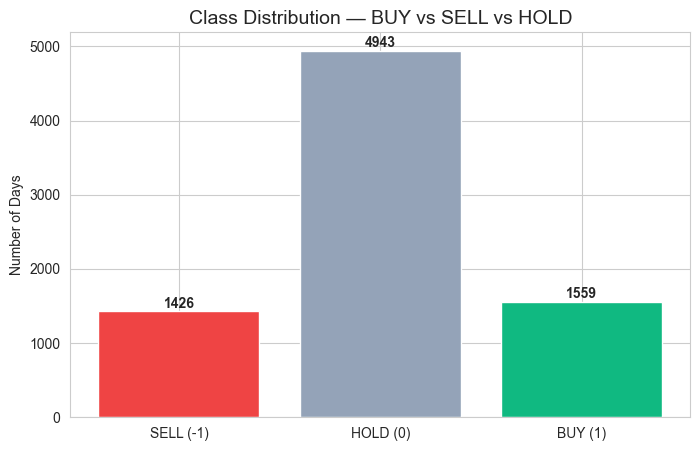


📊 Imbalance check:
   HOLD percentage: 62.3%


In [2]:
# Cell 2 — Class distribution
target_counts = df["Target"].value_counts().sort_index()
print(target_counts)

# Visualize
plt.figure(figsize=(8, 5))
colors = ["#ef4444", "#94a3b8", "#10b981"]  # Red SELL, Grey HOLD, Green BUY
labels = ["SELL (-1)", "HOLD (0)", "BUY (1)"]

plt.bar(labels, target_counts.values, color=colors)
plt.title("Class Distribution — BUY vs SELL vs HOLD", fontsize=14)
plt.ylabel("Number of Days")
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.show()

print(f"\n📊 Imbalance check:")
print(f"   HOLD percentage: {target_counts[0] / len(df) * 100:.1f}%")

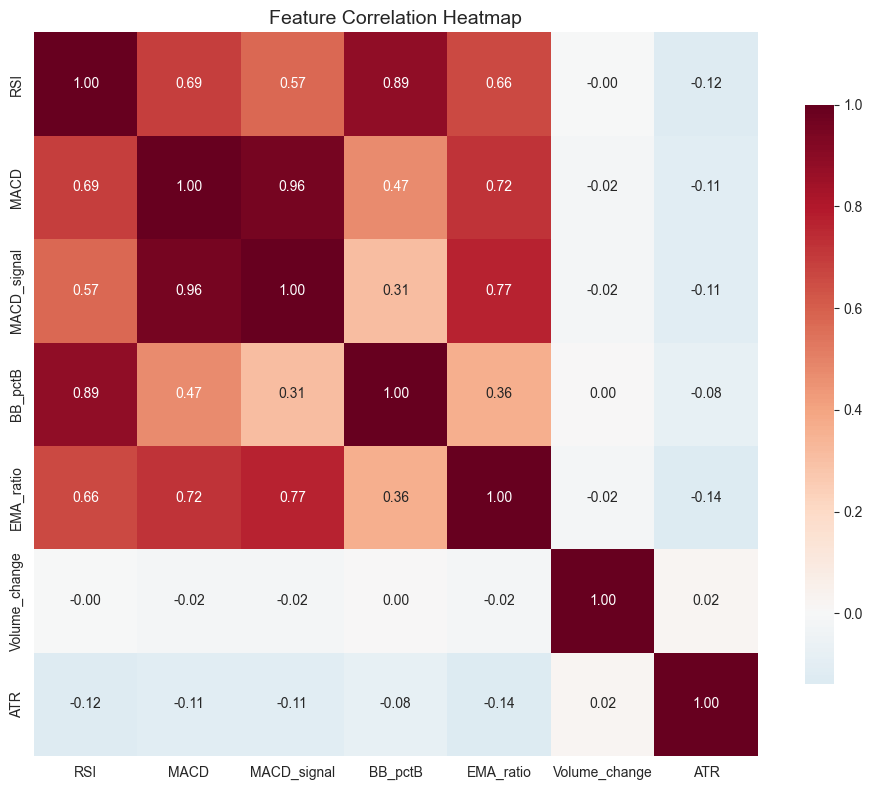

In [3]:
# Cell 3 — Are any indicators redundant?
features = ["RSI", "MACD", "MACD_signal", "BB_pctB", "EMA_ratio", "Volume_change", "ATR"]
corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".2f",
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\Rudranil\AppData\Local\Temp\ipykernel_5836\4023972622.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y=feat, ax=ax,
C:\Users\Rudranil\AppData\Local\Temp\ipykernel_5836\4023972622.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["SELL", "HOLD", "BUY"])
C:\Users\Rudranil\AppData\Local\Temp\ipykernel_5836\4023972622.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y=feat, ax=ax,
C:\Users\Rudranil\AppData\Local\Temp\ipykernel_5836\4023972622.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.

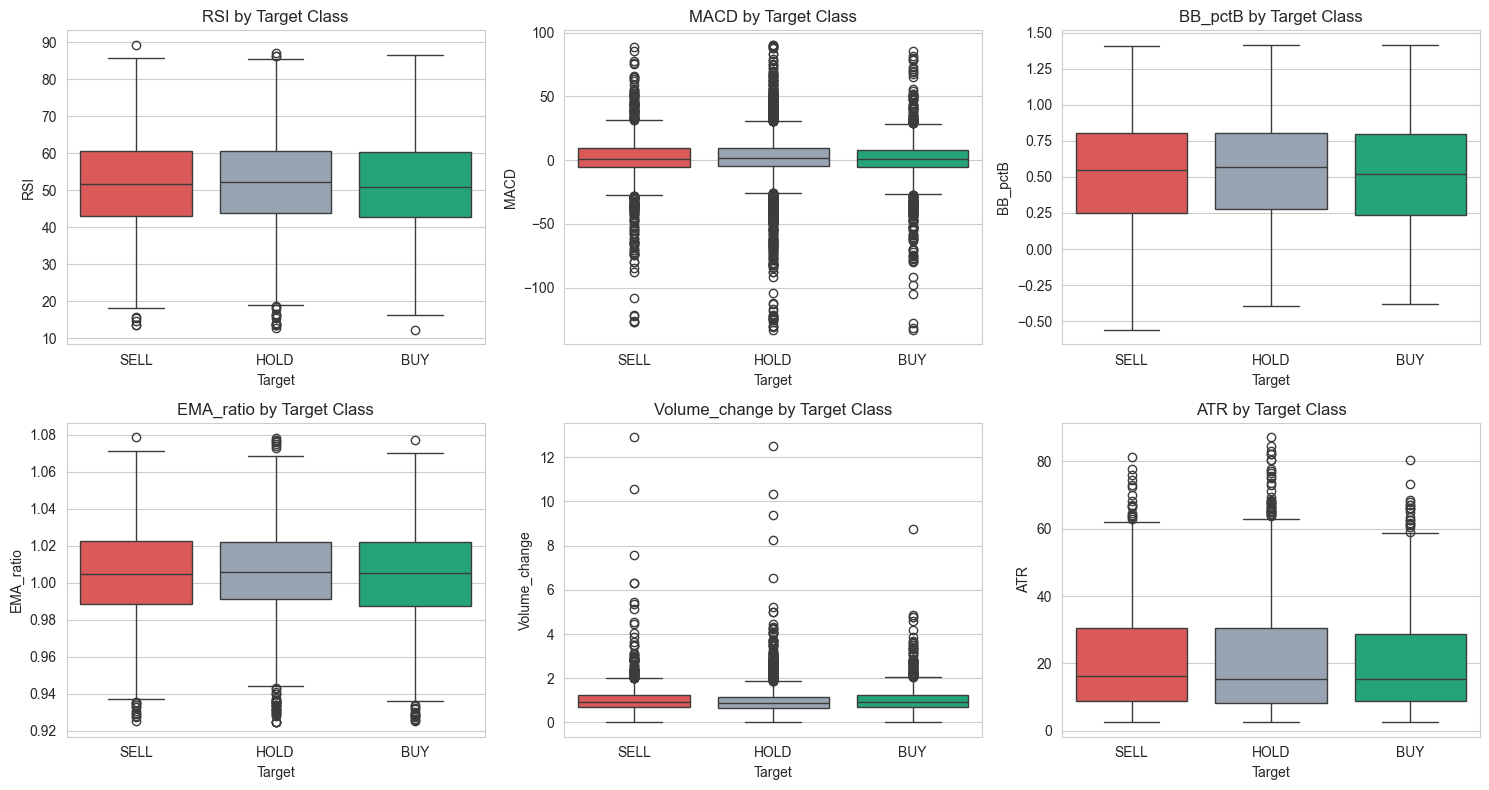

In [4]:
# Cell 4 — Do indicators differ between BUY/SELL/HOLD days?
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_to_plot = ["RSI", "MACD", "BB_pctB", "EMA_ratio", "Volume_change", "ATR"]

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=df, x="Target", y=feat, ax=ax,
                palette=["#ef4444", "#94a3b8", "#10b981"])
    ax.set_title(f"{feat} by Target Class")
    ax.set_xticklabels(["SELL", "HOLD", "BUY"])

plt.tight_layout()
plt.show()

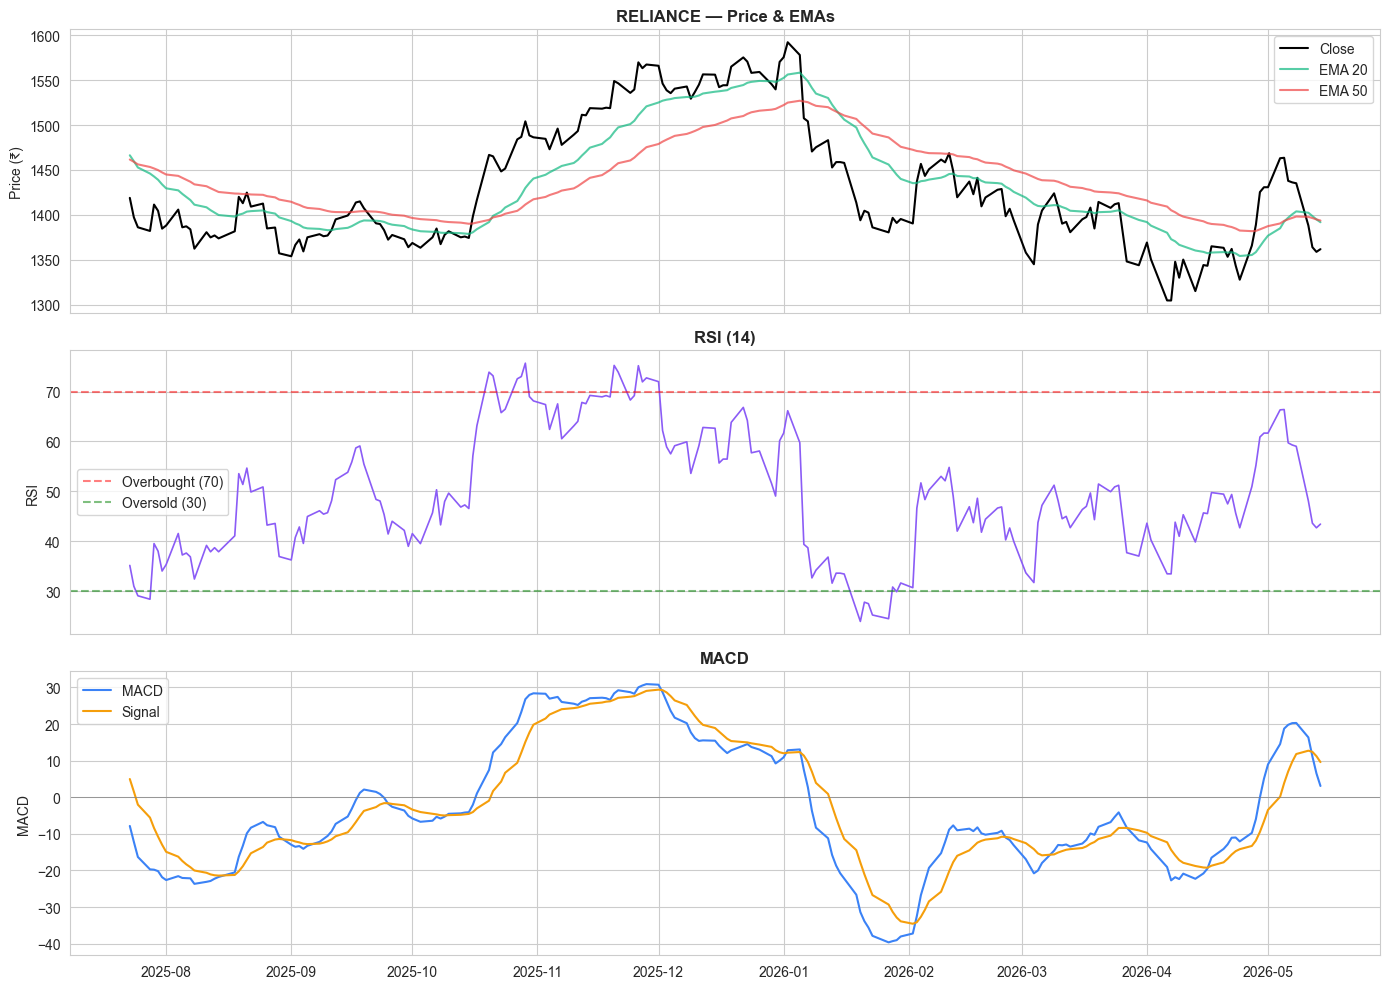

In [5]:
# Cell 5 — Plot RELIANCE with indicators
stock = df[df["Ticker"] == "RELIANCE.NS"].copy().tail(250)  # Last 1 year

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: Price + EMAs
axes[0].plot(stock["Date"], stock["Close"], label="Close", color="black", linewidth=1.5)
axes[0].plot(stock["Date"], stock["EMA_20"], label="EMA 20", color="#10b981", alpha=0.7)
axes[0].plot(stock["Date"], stock["EMA_50"], label="EMA 50", color="#ef4444", alpha=0.7)
axes[0].set_title("RELIANCE — Price & EMAs", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].set_ylabel("Price (₹)")

# Plot 2: RSI
axes[1].plot(stock["Date"], stock["RSI"], color="#8b5cf6", linewidth=1.2)
axes[1].axhline(70, color="red", linestyle="--", alpha=0.5, label="Overbought (70)")
axes[1].axhline(30, color="green", linestyle="--", alpha=0.5, label="Oversold (30)")
axes[1].set_title("RSI (14)", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].set_ylabel("RSI")

# Plot 3: MACD
axes[2].plot(stock["Date"], stock["MACD"], label="MACD", color="#3b82f6")
axes[2].plot(stock["Date"], stock["MACD_signal"], label="Signal", color="#f59e0b")
axes[2].axhline(0, color="grey", linewidth=0.5)
axes[2].set_title("MACD", fontsize=12, fontweight="bold")
axes[2].legend()
axes[2].set_ylabel("MACD")

plt.tight_layout()
plt.show()

In [6]:
# Cell 6 — Get the full picture
print("=" * 60)
print("DATASET HEALTH REPORT")
print("=" * 60)
print(f"Total samples: {len(df):,}")
print(f"Total stocks: {df['Ticker'].nunique()}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Missing values: {df.isna().sum().sum()}")

print("\nFeature stats:")
print(df[features].describe().round(2))

DATASET HEALTH REPORT
Total samples: 7,928
Total stocks: 10
Date range: 2021-07-26 00:00:00 → 2026-05-14 00:00:00
Missing values: 0

Feature stats:
           RSI     MACD  MACD_signal  BB_pctB  EMA_ratio  Volume_change  \
count  7928.00  7928.00      7928.00  7928.00    7928.00        7928.00   
mean     51.91     1.22         1.25     0.54       1.01           1.01   
std      12.23    19.97        18.85     0.33       0.02           0.60   
min      12.19  -133.01      -126.97    -0.56       0.92           0.00   
25%      43.39    -4.87        -4.59     0.27       0.99           0.68   
50%      51.80     1.42         1.52     0.55       1.01           0.89   
75%      60.47     9.33         8.84     0.80       1.02           1.18   
max      89.32    90.47        82.21     1.42       1.08          12.91   

           ATR  
count  7928.00  
mean     20.63  
std      15.01  
min       2.52  
25%       8.51  
50%      15.61  
75%      30.10  
max      87.11  
